# Job Search with Separation

This module solves for the optimal policy of an agent who can be either
unemployed or employed. The key features of the model are:

## Model Setup

- Agent receives wage offers w from a finite set when unemployed
- Wage offers follow a Markov chain with transition matrix P
- Jobs terminate with probability α each period (separation rate)
- Unemployed workers receive compensation c per period
- Future payoffs discounted by factor β ∈ (0,1)

## Decision Problem

When unemployed and receiving wage offer w, the agent chooses between:
1. Accept offer w: Become employed at wage w
2. Reject offer: Remain unemployed, receive c, get new offer next period

## Value Functions

- v_u*(w): Value of being unemployed when current wage offer is w
- v_e*(w): Value of being employed at wage w

## Bellman Equations

The unemployed worker's value function satisfies:

$$v_u^*(w) = \max\{v_e^*(w), c + \beta \sum_{w'} v_u^*(w') P(w,w')\}$$

The employed worker's value function satisfies:

$$v_e^*(w) = w + \beta[\alpha \sum_{w'} v_u^*(w') P(w,w') + (1-\alpha) v_e^*(w)]$$

## Computational Approach

1. Solve the employed value function analytically:
   $$v_e^*(w) = \frac{1}{1-\beta(1-\alpha)} \cdot (w + \alpha\beta(Pv_u^*)(w))$$

2. Substitute into unemployed Bellman equation to get:
   $$v_u^*(w) = \max\left\{\frac{1}{1-\beta(1-\alpha)} \cdot (w + \alpha\beta(Pv_u^*)(w)), c + \beta(Pv_u^*)(w)\right\}$$

3. Use value function iteration to solve for v_u*
4. Compute optimal policy: accept if v_e*(w) ≥ c + β(Pv_u*)(w)

The optimal policy is a reservation wage strategy: accept all wages above
some threshold w*.

## Code

We use the following imports:

In [1]:
from quantecon.markov import tauchen
import numpy as np
from typing import NamedTuple
import matplotlib.pyplot as plt
from numba import jit

First, we implement the successive approximation algorithm:

In [2]:
def successive_approx(
        T,                         # Operator (callable)
        x_0,                       # Initial condition
        tolerance: float = 1e-6,   # Error tolerance
        max_iter: int = 100_000,   # Max iteration bound
        verbose: bool = False
    ):
    """Computes the approximate fixed point of T via successive
    approximation."""
    x = x_0
    error = tolerance + 1
    k = 1
    while (error > tolerance) and (k <= max_iter):
        x_new = T(x)
        error = np.max(np.abs(x_new - x))
        x = x_new
        k += 1
    if error <= tolerance:
        if verbose:
            print(f"Terminated successfully in {k} iterations.")
    else:
        print("Warning: hit iteration bound.")
    return x

Let's set up a `Model` class to store information needed to solve the model:

In [3]:
class Model(NamedTuple):
    n: int
    w_vals: np.ndarray
    P: np.ndarray
    β: float
    c: float
    α: float

The function below holds default values and creates a `Model` instance:

In [4]:
def create_js_with_sep_model(
        n: int = 200,          # wage grid size
        ρ: float = 0.9,        # wage persistence
        ν: float = 0.2,        # wage volatility
        β: float = 0.96,       # discount factor
        α: float = 0.1,        # separation rate
        c: float = 1.5         # unemployment compensation
    ) -> Model:
    """Creates an instance of the job search model with separation."""
    mc = tauchen(n, ρ, ν)
    w_vals, P = np.exp(mc.state_values), mc.P
    return Model(n, w_vals, P, β, c, α)



Here's the Bellman operator for the unemployed worker's value function:

In [5]:
@jit
def T(v: np.ndarray, model: Model) -> np.ndarray:
    """The Bellman operator for the value of being unemployed."""
    n, w_vals, P, β, c, α = model
    d = 1 / (1 - β * (1 - α))
    accept = d * (w_vals + α * β * P @ v)
    reject = c + β * P @ v
    return np.maximum(accept, reject)

The next function computes the optimal policy under the assumption that v is
the value function:

In [6]:
@jit
def get_greedy(v: np.ndarray, model: Model) -> np.ndarray:
    """Get a v-greedy policy."""
    n, w_vals, P, β, c, α = model
    d = 1 / (1 - β * (1 - α))
    accept = d * (w_vals + α * β * P @ v)
    reject = c + β * P @ v
    σ = accept >= reject
    return σ

Here's a routine for value function iteration:

In [7]:
def vfi(model: Model, verbose: bool = False):
    """Solve by VFI."""
    v_init = np.zeros(model.w_vals.shape)
    v_star = successive_approx(lambda v: T(v, model), v_init, verbose)
    σ_star = get_greedy(v_star, model)
    return v_star, σ_star

## Computing the Solution

Let's solve the model and plot the results:

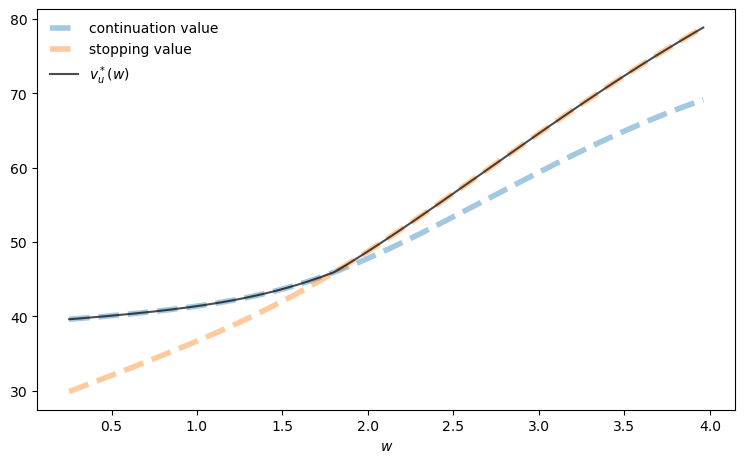

In [8]:
model = create_js_with_sep_model()
n, w_vals, P, β, c, α = model
v_star, σ_star = vfi(model)

d = 1 / (1 - β * (1 - α))
accept = d * (w_vals + α * β * P @ v_star)
h_star = c + β * P @ v_star

w_star = np.inf
for (i, w) in enumerate(w_vals):
    if accept[i] >= h_star[i]:
        w_star = w
        break

assert w_star != np.inf, "Agent never accepts"

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(w_vals, h_star, linewidth=4, ls="--", alpha=0.4,
        label="continuation value")
ax.plot(w_vals, accept, linewidth=4, ls="--", alpha=0.4,
        label="stopping value")
ax.plot(w_vals, v_star, "k-", alpha=0.7, label=r"$v_u^*(w)$")
ax.legend(frameon=False)
ax.set_xlabel(r"$w$")
plt.show()



## Sensitivity Analysis

Let's examine how reservation wages change with the separation rate α:

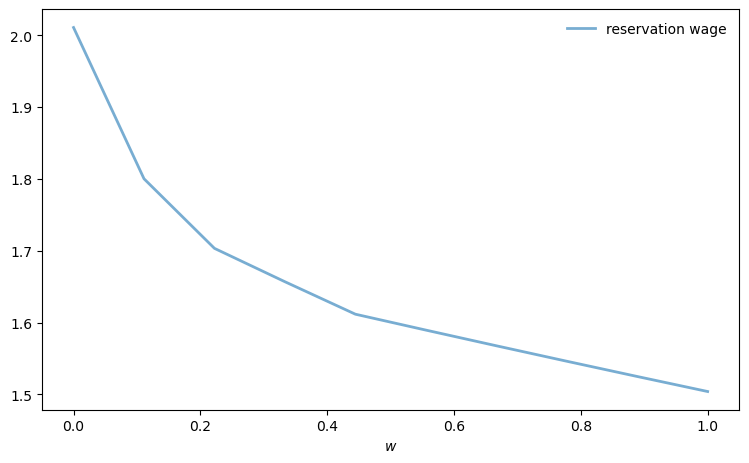

In [9]:
α_vals: np.ndarray = np.linspace(0.0, 1.0, 10)

w_star_vec = np.empty_like(α_vals)
for (i_α, α) in enumerate(α_vals):
    model = create_js_with_sep_model(α=α)
    n, w_vals, P, β, c, α = model
    v_star, σ_star = vfi(model)

    d = 1 / (1 - β * (1 - α))
    accept = d * (w_vals + α * β * P @ v_star)
    h_star = c + β * P @ v_star

    w_star = np.inf
    for (i_w, w) in enumerate(w_vals):
        if accept[i_w] >= h_star[i_w]:
            w_star = w
            break

    assert w_star != np.inf, "Agent never accepts"
    w_star_vec[i_α] = w_star

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(α_vals, w_star_vec, linewidth=2, alpha=0.6,
        label="reservation wage")
ax.legend(frameon=False)
ax.set_xlabel(r"$\alpha$")
ax.set_xlabel(r"$w$")
plt.show()



## Employment Simulation

Now let's simulate the employment dynamics of a single agent under the optimal policy:

In [10]:
@jit
def weighted_choice(probs):
    """Numba-compatible weighted random choice."""
    cumsum = np.cumsum(probs)
    return np.searchsorted(cumsum, np.random.random())

@jit
def update_agent(is_employed, wage_idx, model, σ_star):

    n, w_vals, P, β, c, α = model

    if is_employed: # Employed update

        # Separation => become unemployed and draw new wage
        if np.random.random() < α:
            is_employed = False
            wage_idx = weighted_choice(P[wage_idx, :])

        # No separation => employment status and wage unchanged
        else:
            pass

    else: # Unemployed update

        # Accept => become employed and hold wage unchanged
        if σ_star[wage_idx]:
            is_employed = True

        # Reject => stay unemployed and update wage
        else:
            wage_idx = weighted_choice(P[wage_idx, :])

    return is_employed, wage_idx

In [11]:
def simulate_employment_path(
        model: Model,     # Model detaisl
        T: int = 1_000,   # Simulation length
        seed: int = 42    # Set seed for simulation
    ):
    """
    Simulate employment path for T periods starting from unemployment.

    """
    np.random.seed(seed)
    # Unpack, solve for optimal policy
    n, w_vals, P, β, c, α = model
    v_star, σ_star = vfi(model)

    # A series wage_path to track the wage that the agent will use to
    # update their wage offer (constant when employed)
    wage_path = np.zeros(T)
    # A series to track employment status (0 = unemployed, 1 = employed)
    employment_status = np.zeros(T, dtype=int)

    # Start unemployed with uniform wage draw
    is_employed = False
    wage_idx = np.random.randint(0, n)

    for t in range(T):
        wage_path[t] = w_vals[wage_idx]
        employment_status[t] = is_employed
        is_employed, wage_idx = update_agent(
            is_employed, wage_idx, model, σ_star
        )

    return wage_path, employment_status

Let's create a comprehensive plot of the employment simulation:

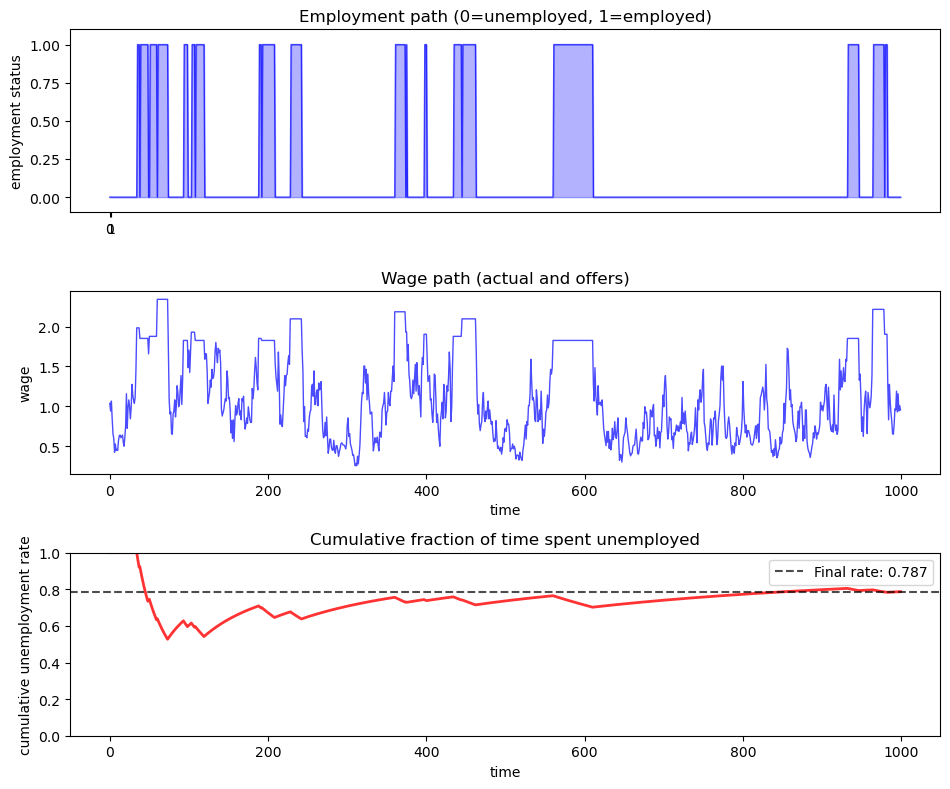

In [12]:

model = create_js_with_sep_model()

wage_path, employment_status = simulate_employment_path(model)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9.6, 8))

# Plot employment status
ax1.plot(employment_status, 'b-', alpha=0.7, linewidth=1)
ax1.fill_between(
    range(len(employment_status)), employment_status, alpha=0.3, color='blue'
)
ax1.set_ylabel('employment status')
ax1.set_title('Employment path (0=unemployed, 1=employed)')
ax1.set_xticks((0, 1))
ax1.set_ylim(-0.1, 1.1)

# Plot wage path with employment status coloring
ax2.plot(wage_path, 'b-', alpha=0.7, linewidth=1)
ax2.set_xlabel('time')
ax2.set_ylabel('wage')
ax2.set_title('Wage path (actual and offers)')

# Plot cumulative fraction of time unemployed
unemployed_indicator = (employment_status == 0).astype(int)
cumulative_unemployment = (
    np.cumsum(unemployed_indicator) /
    np.arange(1, len(employment_status) + 1)
)

ax3.plot(cumulative_unemployment, 'r-', alpha=0.8, linewidth=2)
ax3.axhline(y=np.mean(unemployed_indicator), color='black',
            linestyle='--', alpha=0.7,
            label=f'Final rate: {np.mean(unemployed_indicator):.3f}')
ax3.set_xlabel('time')
ax3.set_ylabel('cumulative unemployment rate')
ax3.set_title('Cumulative fraction of time spent unemployed')
ax3.legend()
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary statistics

## Results Summary

The simulation demonstrates the model's key predictions:

1. **Optimal Policy**: The agent follows a reservation wage strategy
2. **Employment Dynamics**: Realistic patterns of job search, acceptance, and separation
3. **Steady State**: The cumulative unemployment rate converges to the theoretical prediction
4. **Labor Market Flows**: Clear cycles between unemployment and employment spells

The model successfully captures the essential features of labor market dynamics with job separation, showing how workers optimally balance the trade-off between accepting current offers versus waiting for better opportunities.

## Cross-Sectional Analysis

Now let's simulate many agents simultaneously to examine the cross-sectional unemployment rate:

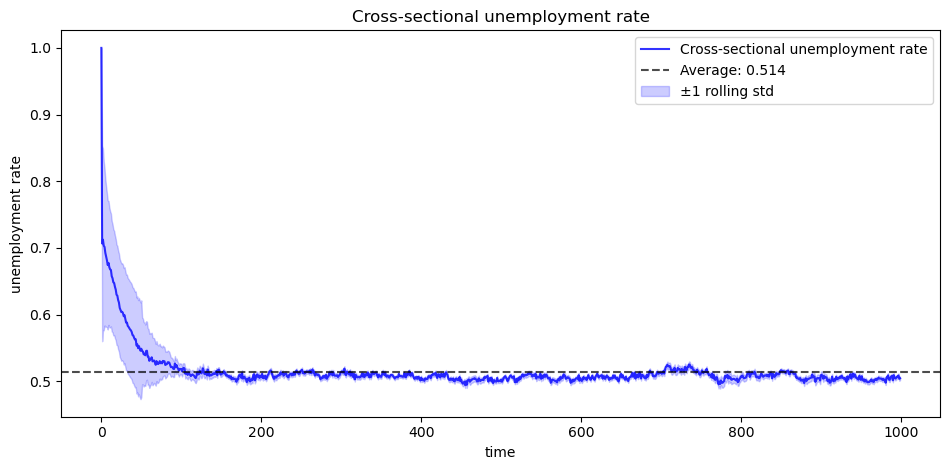

In [13]:
@jit
def simulate_cross_section_numba(
        employment_matrix, is_employed, wage_indices, model, σ_star,
        n_agents, T
    ):
    """Numba-accelerated simulation loop."""
    for t in range(T):
        for agent in range(n_agents):
            employment_matrix[agent, t] = 1 if is_employed[agent] else 0
            is_employed[agent], wage_indices[agent] = update_agent(
                is_employed[agent], wage_indices[agent], model, σ_star
            )

def simulate_cross_section(
        model: Model,
        n_agents: int = 10_000,
        T: int = 1000,
        seed: int = 42
    ) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate employment paths for many agents simultaneously.

    Parameters:
    - model: Model instance with parameters
    - n_agents: Number of agents to simulate
    - T: Number of periods to simulate
    - seed: Random seed for reproducibility

    Returns:
    - unemployment_rates: Fraction of agents unemployed at each period
    - employment_matrix: n_agents x T matrix of employment status
    """
    np.random.seed(seed)

    # Solve for optimal policy
    v_star, σ_star = vfi(model)
    n, w_vals, P, β, c, α = model

    # Initialize arrays
    employment_matrix = np.zeros((n_agents, T), dtype=np.int32)
    wage_indices = np.random.randint(0, n, size=n_agents)
    is_employed = np.zeros(n_agents, dtype=np.bool_)

    # Run the accelerated simulation
    simulate_cross_section_numba(
        employment_matrix, is_employed, wage_indices, model, σ_star,
        n_agents, T
    )

    # Calculate unemployment rate at each period
    unemployment_rates = 1 - np.mean(employment_matrix, axis=0)

    return unemployment_rates, employment_matrix



model = create_js_with_sep_model()

unemployment_rates, employment_matrix = simulate_cross_section(model)

fig, ax = plt.subplots(figsize=(9.6, 4.8))

# Plot unemployment rate over time
ax.plot(unemployment_rates, 'b-', alpha=0.8, linewidth=1.5,
        label='Cross-sectional unemployment rate')

# Add horizontal line for average unemployment rate
avg_unemployment = np.mean(unemployment_rates)
ax.axhline(y=avg_unemployment, color='k', linestyle='--', alpha=0.7,
           label=f'Average: {avg_unemployment:.3f}')

# Add shaded region for ±1 standard deviation
window_size = 50
rolling_std = np.array([
    np.std(unemployment_rates[max(0, t-window_size):t+1])
    for t in range(len(unemployment_rates))
])

ax.fill_between(range(len(unemployment_rates)),
                unemployment_rates - rolling_std,
                unemployment_rates + rolling_std,
                alpha=0.2, color='blue',
                label='±1 rolling std')

ax.set_xlabel('time')
ax.set_ylabel('unemployment rate')
ax.set_title(f'Cross-sectional unemployment rate')
ax.legend()

plt.tight_layout()
plt.show()